<a href="https://colab.research.google.com/github/hariharan-075/ML/blob/main/2420080075_Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Random Forest Accuracy: 0.9722222222222222
Out-of-Bag Error: 0.029227557411273475


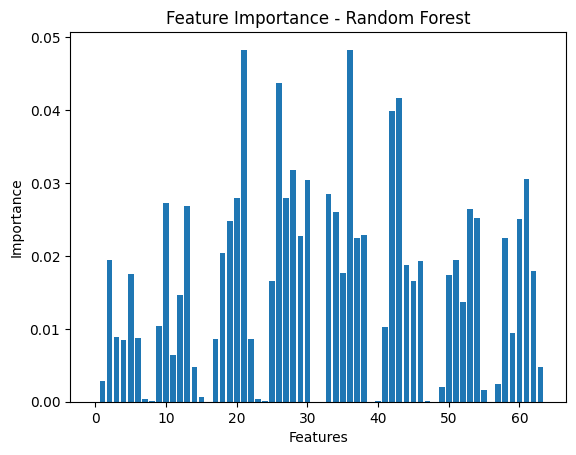

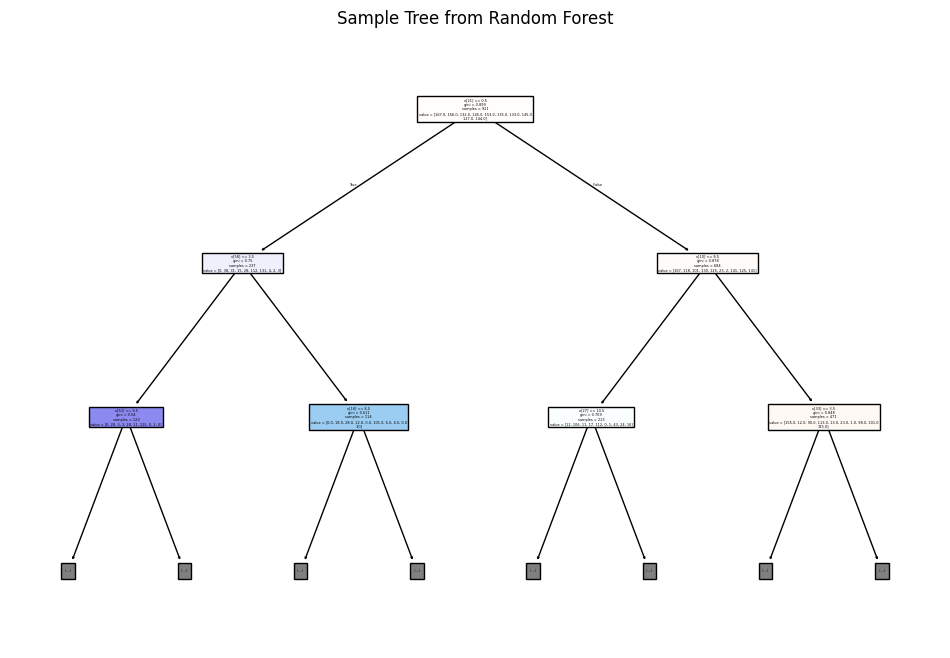

In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
import time

# Load dataset
digits = load_digits()
X = digits.data
y = digits.target

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest model
rf = RandomForestClassifier(n_estimators=100, max_depth=10, oob_score=True, random_state=42)

start = time.time()
rf.fit(X_train, y_train)
train_time_rf = time.time() - start

# Prediction
start = time.time()
y_pred_rf = rf.predict(X_test)
pred_time_rf = time.time() - start

# Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

# Out of bag error
oob_error = 1 - rf.oob_score_
print("Out-of-Bag Error:", oob_error)

# Feature importance plot
importances = rf.feature_importances_
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

# Visualize one tree
plt.figure(figsize=(12,8))
plot_tree(rf.estimators_[0], filled=True, max_depth=2)
plt.title("Sample Tree from Random Forest")
plt.show()

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import time

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=1
)

# Training time
start = time.time()
ada.fit(X_train, y_train)
train_time_ada = time.time() - start

# Prediction time
start = time.time()
y_pred_ada = ada.predict(X_test)
pred_time_ada = time.time() - start

accuracy_ada = accuracy_score(y_test, y_pred_ada)

print("AdaBoost Accuracy:", accuracy_ada)

AdaBoost Accuracy: 0.8277777777777777


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Random Forest", "AdaBoost"],
    "Accuracy": [accuracy_rf, accuracy_ada],
    "Training Time": [train_time_rf, train_time_ada],
    "Prediction Time": [pred_time_rf, pred_time_ada]
})

print(results)

           Model  Accuracy  Training Time  Prediction Time
0  Random Forest  0.972222       0.480009         0.013777
1       AdaBoost  0.827778       0.817796         0.048395


Best Params: {'n_estimators': 100, 'max_depth': None}
Bootstrap Acc: 0.9722222222222222
No Bootstrap Acc: 0.9777777777777777


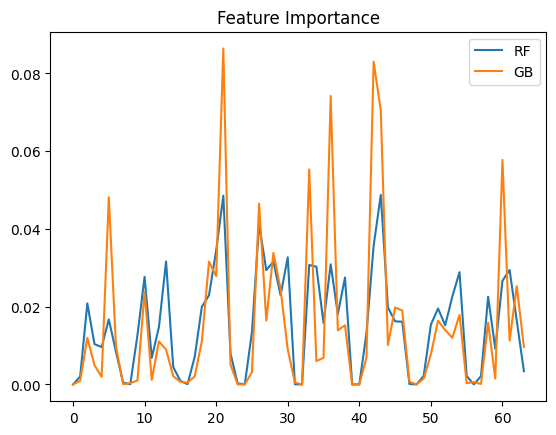

      Model  Accuracy
0        RF  0.977778
1  AdaBoost  0.827778
2        GB  0.969444
3     Stack  0.986111


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load data
digits = load_digits()
X, y = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------- Random Forest --------
rf = RandomForestClassifier(n_estimators=100, max_depth=10, oob_score=True)

t=time.time(); rf.fit(X_train,y_train); train_rf=time.time()-t
t=time.time(); pred_rf=rf.predict(X_test); predt_rf=time.time()-t
acc_rf=accuracy_score(y_test,pred_rf)

# -------- AdaBoost --------
ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),n_estimators=100)

t=time.time(); ada.fit(X_train,y_train); train_ada=time.time()-t
t=time.time(); pred_ada=ada.predict(X_test); predt_ada=time.time()-t
acc_ada=accuracy_score(y_test,pred_ada)

# -------- Gradient Boosting --------
gb = GradientBoostingClassifier()

t=time.time(); gb.fit(X_train,y_train); train_gb=time.time()-t
t=time.time(); pred_gb=gb.predict(X_test); predt_gb=time.time()-t
acc_gb=accuracy_score(y_test,pred_gb)

# -------- Stacking --------
stack = StackingClassifier(
    estimators=[('rf',rf),('ada',ada)],
    final_estimator=LogisticRegression()
)

stack.fit(X_train,y_train)
acc_stack=accuracy_score(y_test,stack.predict(X_test))

# -------- Hyperparameter tuning --------
param={'n_estimators':[50,100,150],'max_depth':[5,10,None]}
search=RandomizedSearchCV(RandomForestClassifier(),param,n_iter=5)
search.fit(X_train,y_train)
print("Best Params:",search.best_params_)

# -------- Bootstrap effect --------
rf1=RandomForestClassifier(bootstrap=True).fit(X_train,y_train)
rf2=RandomForestClassifier(bootstrap=False).fit(X_train,y_train)

print("Bootstrap Acc:",accuracy_score(y_test,rf1.predict(X_test)))
print("No Bootstrap Acc:",accuracy_score(y_test,rf2.predict(X_test)))

# -------- Feature importance --------
plt.plot(rf.feature_importances_,label="RF")
plt.plot(gb.feature_importances_,label="GB")
plt.legend()
plt.title("Feature Importance")
plt.show()

# -------- Results --------
results=pd.DataFrame({
"Model":["RF","AdaBoost","GB","Stack"],
"Accuracy":[acc_rf,acc_ada,acc_gb,acc_stack]
})

print(results)